In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.dates as mdates

c:\Users\Sultan Selin\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
DATA_PATH = (
    Path.cwd().parent
    / "data"
    / "processed"
    / "consumption_validated.parquet"
)

df = pd.read_parquet(DATA_PATH)


[Text(0.5, 1.0, 'line graph all data'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Consumption(MWh)')]

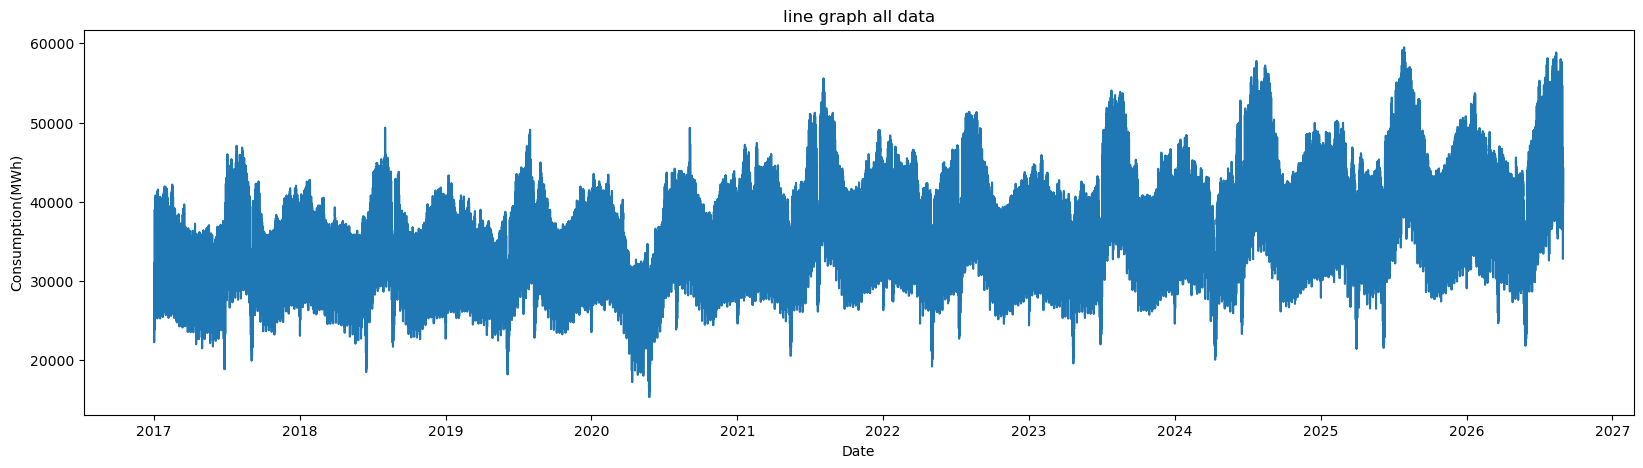

In [4]:
fig = plt.subplots(figsize = (20,5))
g = sns.lineplot(x = 'date', y ='consumption', data = df )
g.set(title= "line graph all data", xlabel = 'Date', ylabel = 'Consumption(MWh)')


In [3]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df


,date,consumption,year,month,day
0,2017-01-01 00:00:00+03:00,27223.06,2017,1,1
1,2017-01-01 01:00:00+03:00,25825.90,2017,1,1
2,2017-01-01 02:00:00+03:00,24252.68,2017,1,1
3,2017-01-01 03:00:00+03:00,22915.47,2017,1,1
4,2017-01-01 04:00:00+03:00,22356.99,2017,1,1
...,...,...,...,...,...
84691,2026-08-30 19:00:00+03:00,43487.20,2026,8,30
84692,2026-08-30 20:00:00+03:00,44306.44,2026,8,30
84693,2026-08-30 21:00:00+03:00,43046.39,2026,8,30
84694,2026-08-30 22:00:00+03:00,41560.60,2026,8,30


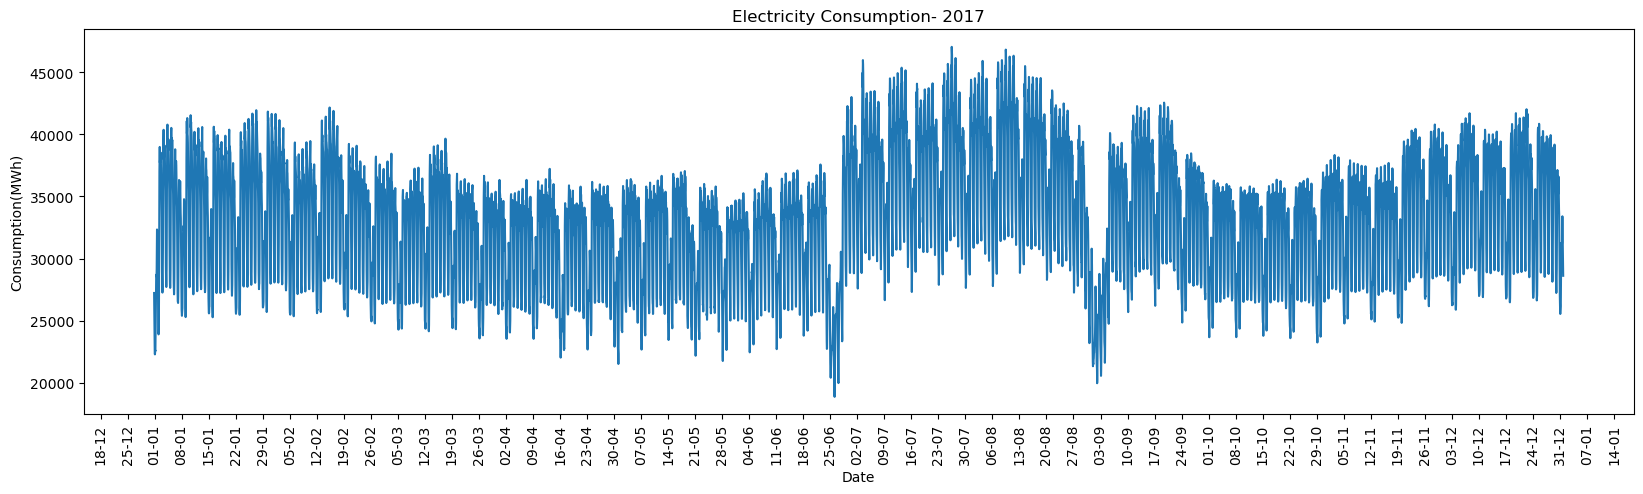

<Figure size 640x480 with 0 Axes>

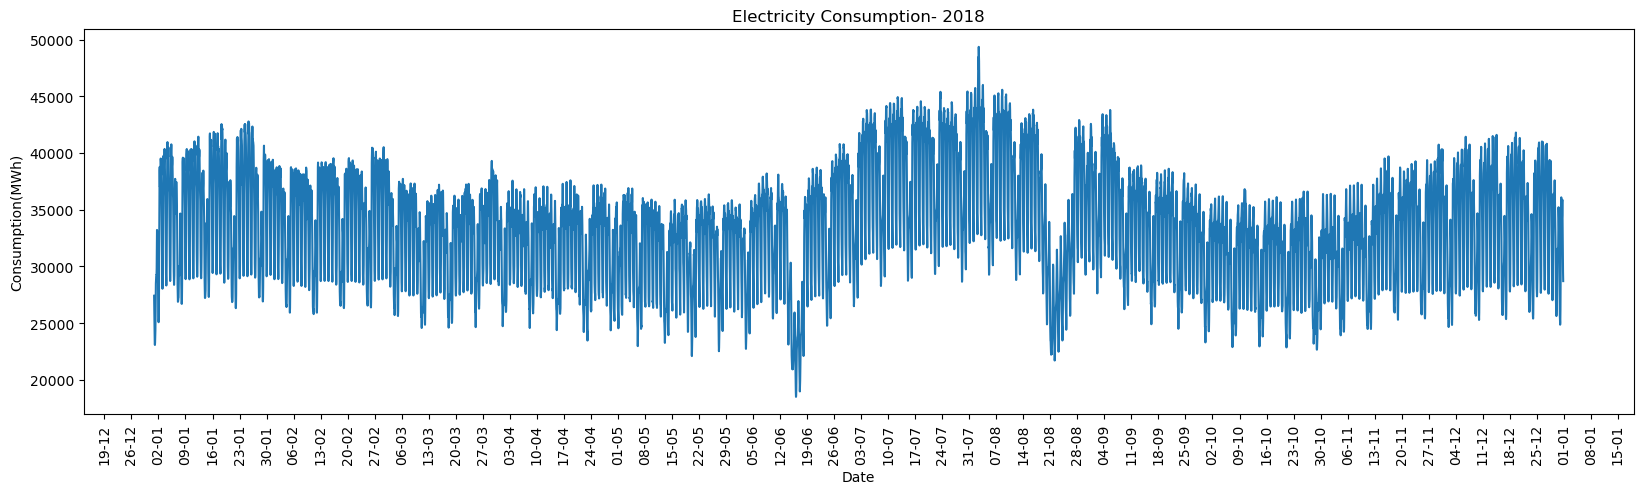

<Figure size 640x480 with 0 Axes>

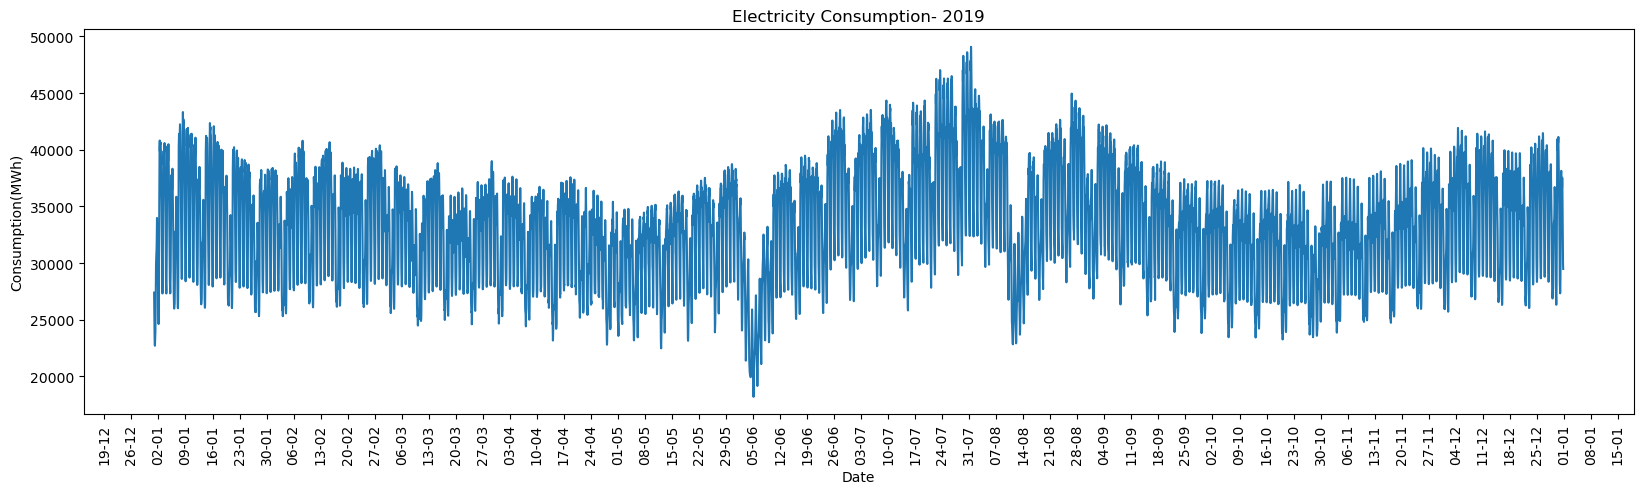

<Figure size 640x480 with 0 Axes>

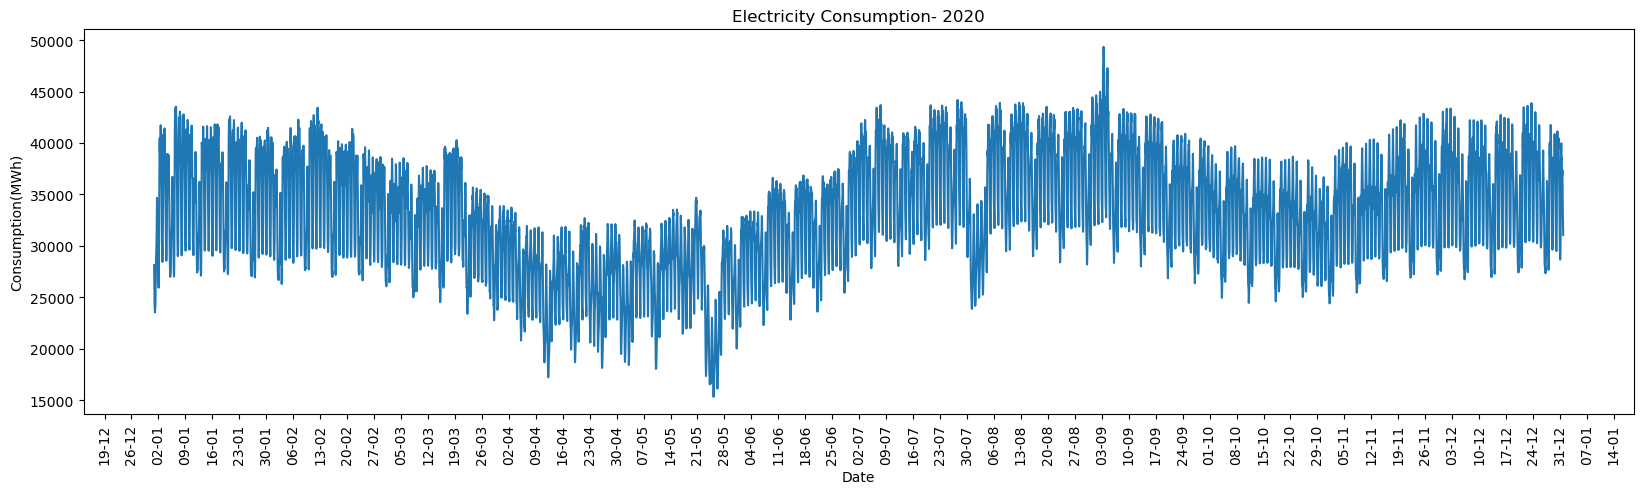

<Figure size 640x480 with 0 Axes>

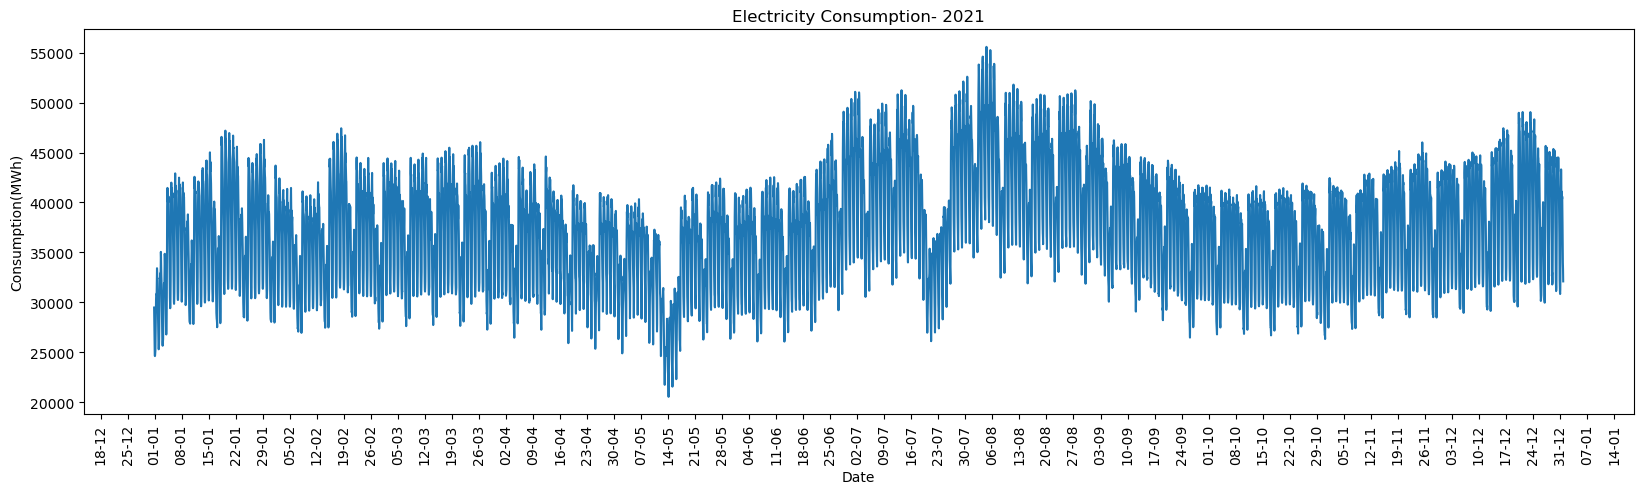

<Figure size 640x480 with 0 Axes>

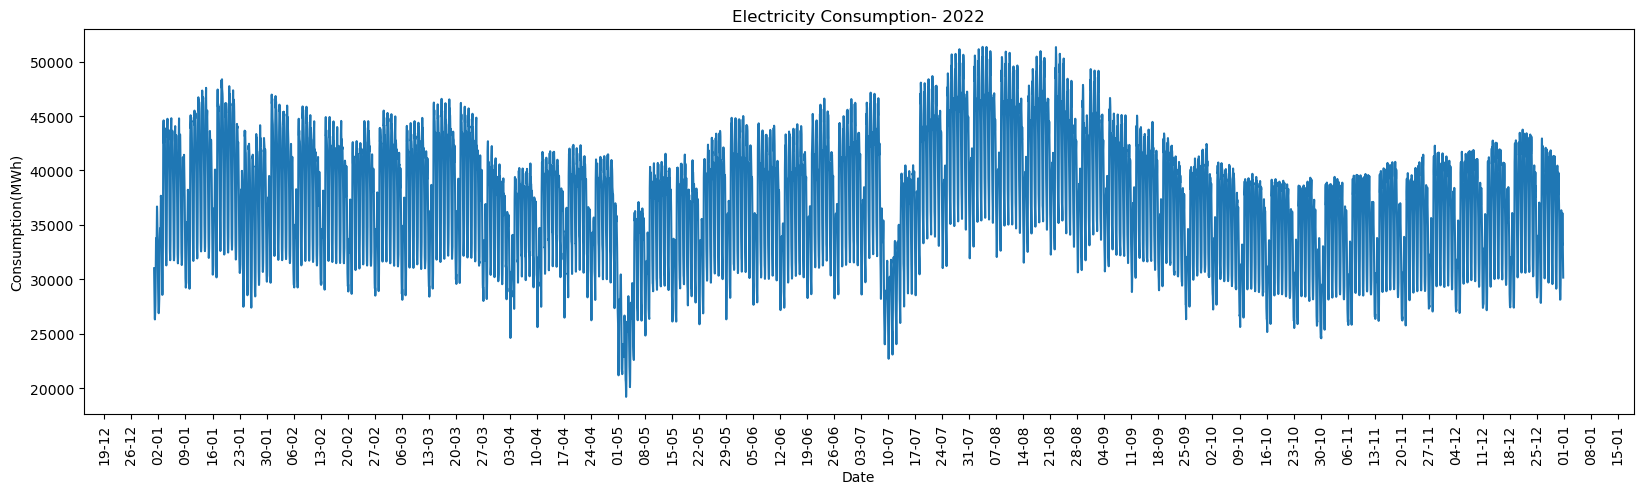

<Figure size 640x480 with 0 Axes>

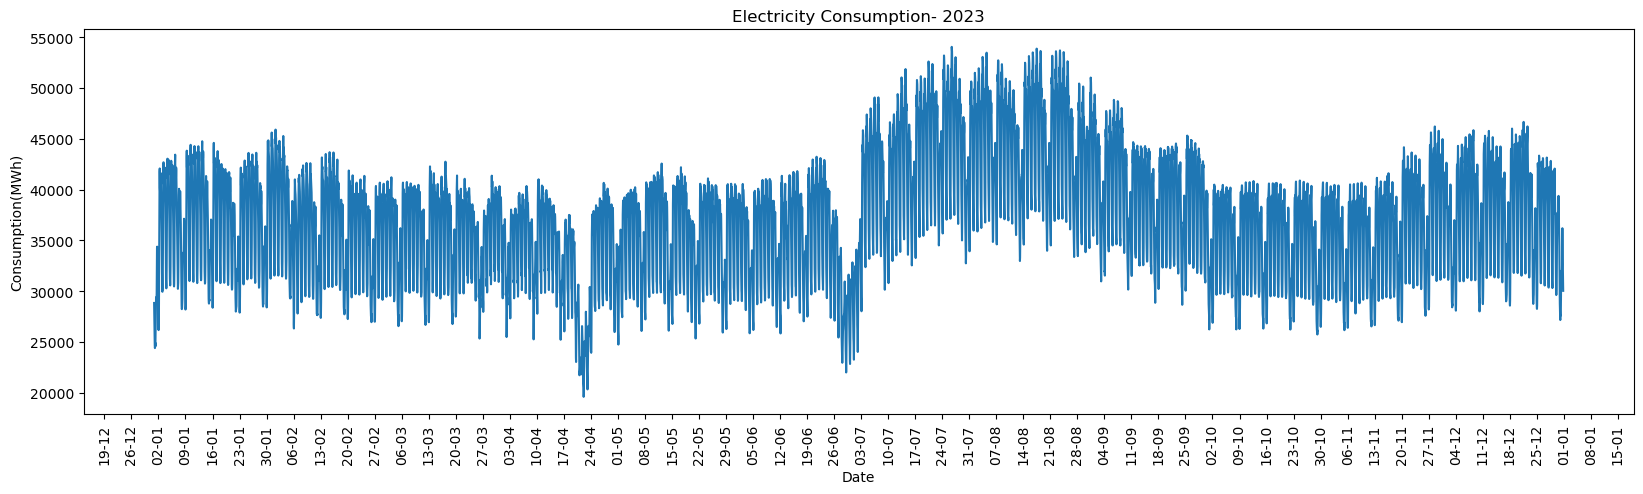

<Figure size 640x480 with 0 Axes>

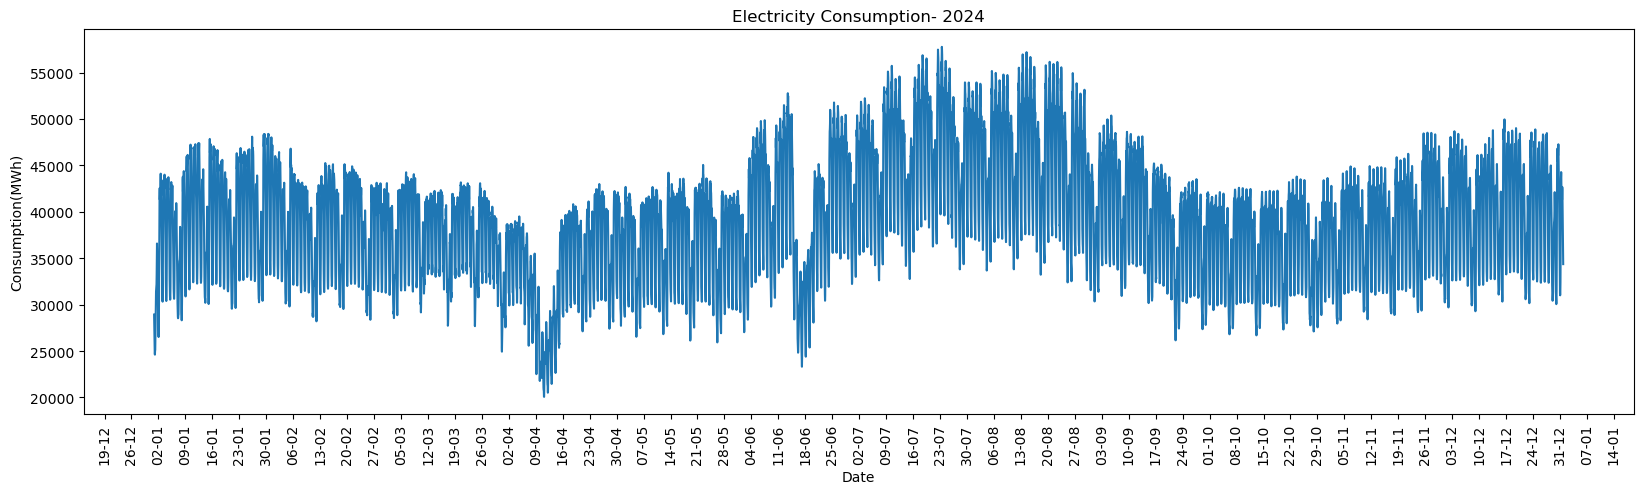

<Figure size 640x480 with 0 Axes>

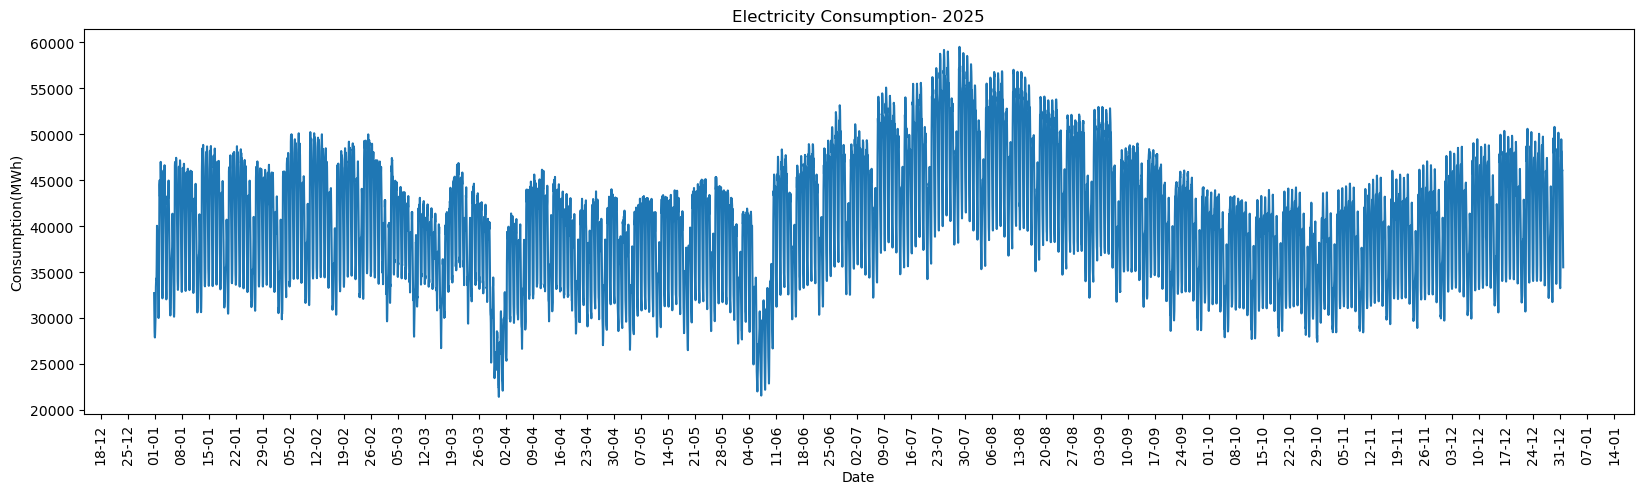

<Figure size 640x480 with 0 Axes>

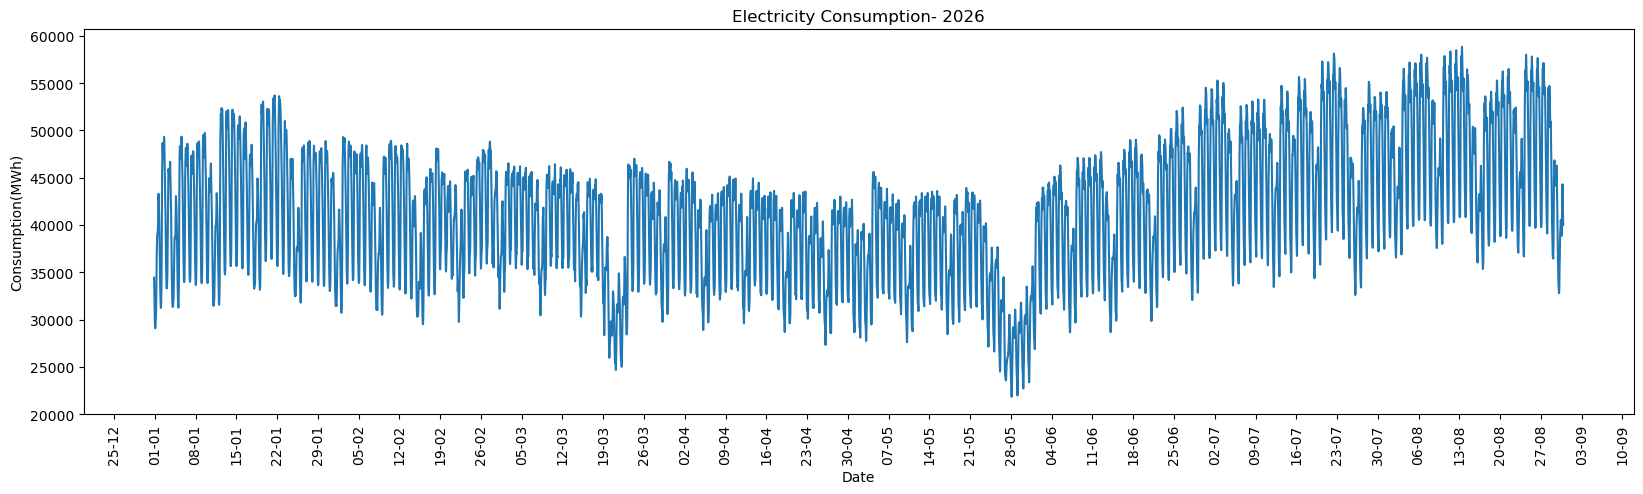

<Figure size 640x480 with 0 Axes>

In [6]:
years = df["year"].unique()
yearly_output = Path.cwd() / "yearly_plots"
yearly_output.mkdir(exist_ok=True)


for year in years:
    yearly_df = df[df["year"] == year]
    fig, ax = plt.subplots(figsize = (20,5))
    sns.lineplot(x = 'date', y ='consumption', data = yearly_df, ax= ax )
    ax.set(title= f"Electricity Consumption- {year}", xlabel = 'Date', ylabel = 'Consumption(MWh)')
    ax.tick_params(axis = 'x', rotation = 90)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
    plt.show()
    plt.savefig(
        yearly_output / f"consumption_{year}.png",
        bbox_inches="tight"
    )


In [4]:
df["weekday"] = df["date"].dt.day_name()
df.head()

,date,consumption,year,month,day,weekday
0,2017-01-01 00:00:00+03:00,27223.06,2017,1,1,Sunday
1,2017-01-01 01:00:00+03:00,25825.90,2017,1,1,Sunday
2,2017-01-01 02:00:00+03:00,24252.68,2017,1,1,Sunday
3,2017-01-01 03:00:00+03:00,22915.47,2017,1,1,Sunday
4,2017-01-01 04:00:00+03:00,22356.99,2017,1,1,Sunday


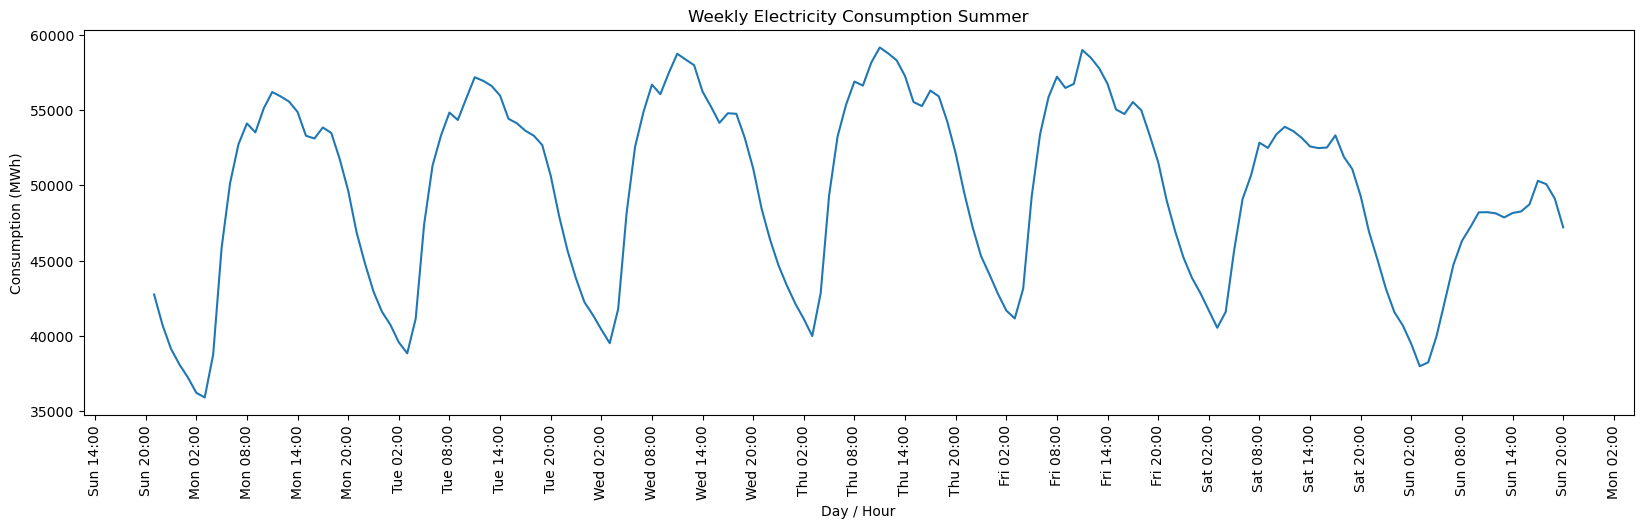

In [8]:
#summer
start_date = "2025-07-21"
end_date = "2025-07-27 23:00"

weekly_df = df[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
]

fig, ax = plt.subplots(figsize=(20, 5))

sns.lineplot(
    data=weekly_df,
    x="date",
    y="consumption",
    ax=ax
)

ax.set(
    title="Weekly Electricity Consumption Summer",
    xlabel="Day / Hour",
    ylabel="Consumption (MWh)"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M"))

ax.tick_params(axis="x", rotation=90)

plt.show()

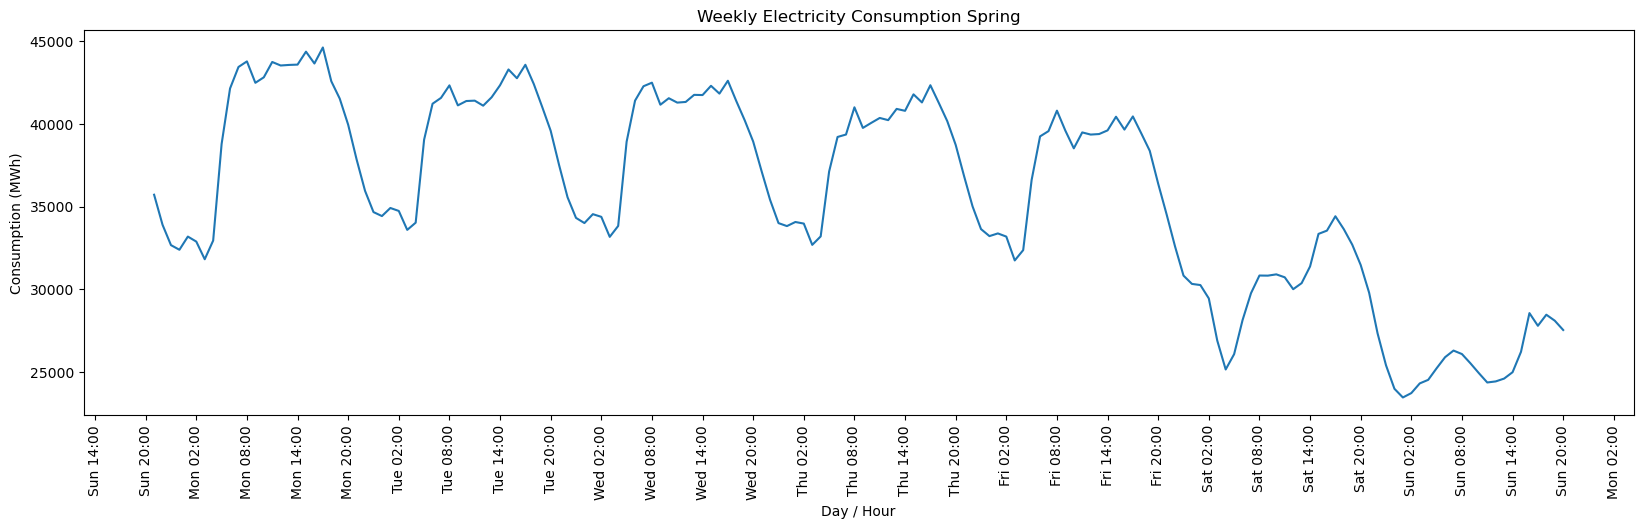

In [9]:
#winter
start_date = "2025-03-24"
end_date = "2025-03-30 23:00"

weekly_df = df[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
]

fig, ax = plt.subplots(figsize=(20, 5))

sns.lineplot(
    data=weekly_df,
    x="date",
    y="consumption",
    ax=ax
)

ax.set(
    title="Weekly Electricity Consumption Spring",
    xlabel="Day / Hour",
    ylabel="Consumption (MWh)"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M"))

ax.tick_params(axis="x", rotation=90)

plt.show()

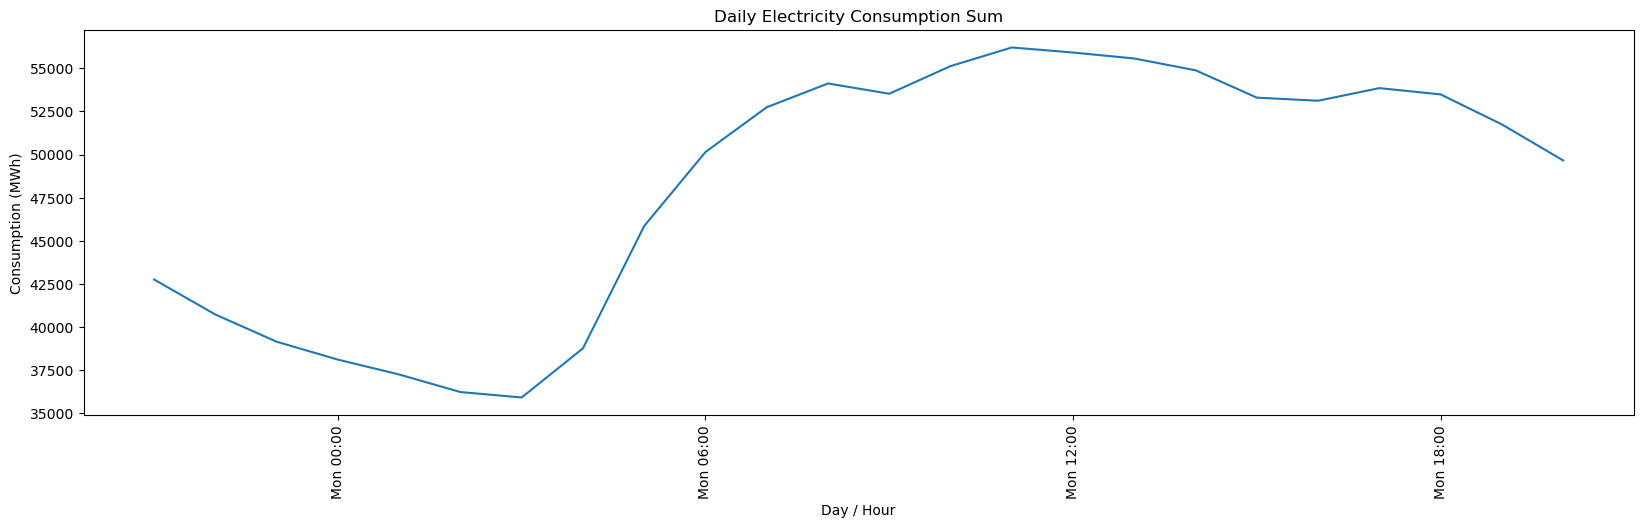

In [10]:
start_date = "2025-07-21 00:00"
end_date = "2025-07-21 23:00"

day_df = df[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
]

fig, ax = plt.subplots(figsize=(20, 5))

sns.lineplot(
    data=day_df,
    x="date",
    y="consumption",
    ax=ax
)

ax.set(
    title="Daily Electricity Consumption Sum",
    xlabel="Day / Hour",
    ylabel="Consumption (MWh)"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M"))

ax.tick_params(axis="x", rotation=90)

plt.show()

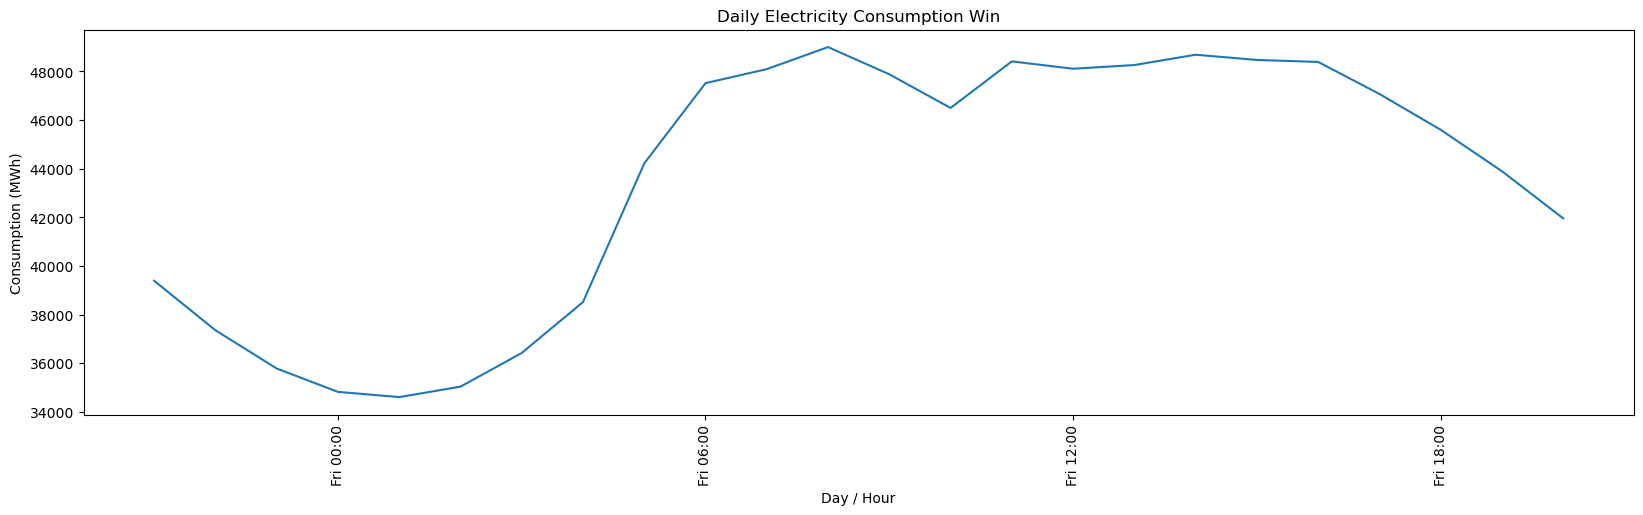

In [11]:
start_date = "2025-02-21 00:00"
end_date = "2025-02-21 23:00"

day_df = df[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
]

fig, ax = plt.subplots(figsize=(20, 5))

sns.lineplot(
    data=day_df,
    x="date",
    y="consumption",
    ax=ax
)

ax.set(
    title="Daily Electricity Consumption Win",
    xlabel="Day / Hour",
    ylabel="Consumption (MWh)"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M"))

ax.tick_params(axis="x", rotation=90)

plt.show()

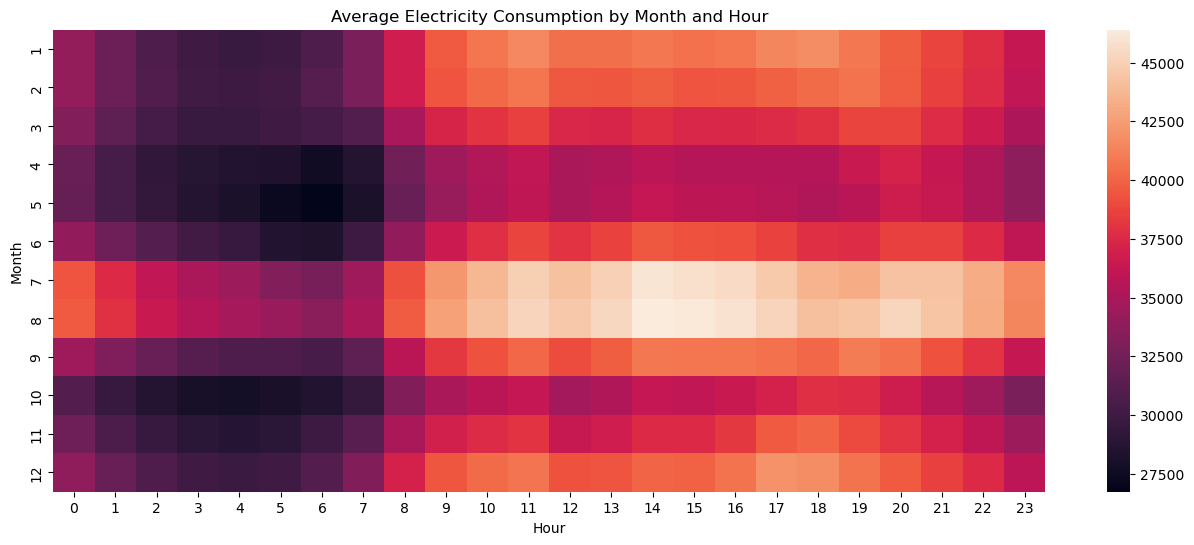

In [12]:
# Hourly & monthly AVG
df.groupby([df["date"].dt.month, df["date"].dt.hour])["consumption"].mean()

heatmap_data = (
    df.groupby(
        [df["date"].dt.month, df["date"].dt.hour]
    )["consumption"]
    .mean()
    .unstack()
)

plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_data
)

plt.xlabel("Hour")
plt.ylabel("Month")
plt.title("Average Electricity Consumption by Month and Hour")

plt.show()


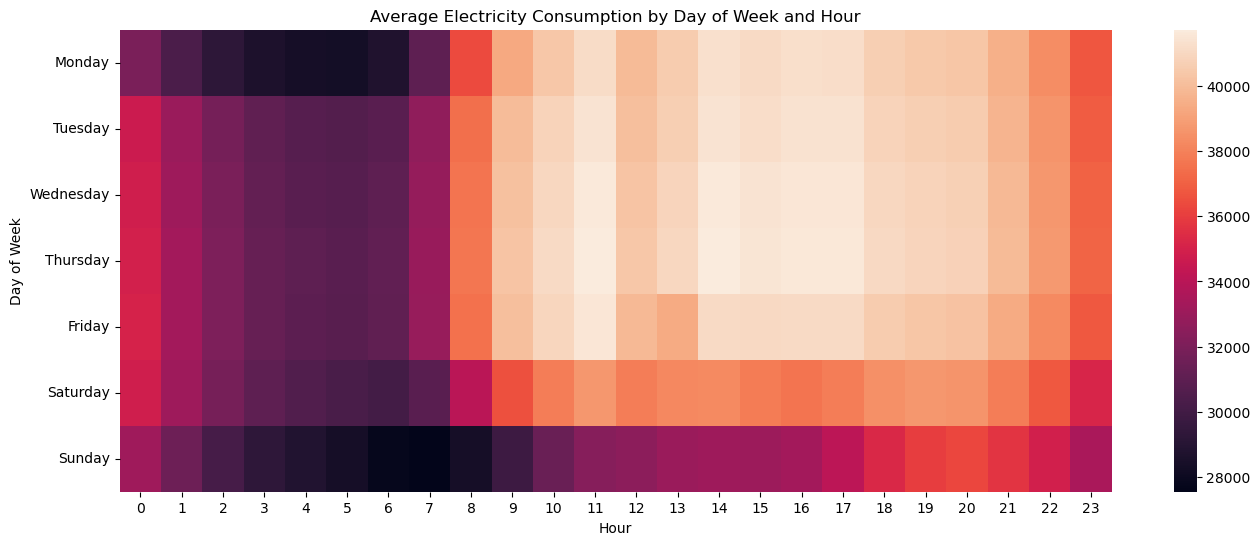

In [13]:
# dayofweek & hourly AVG
df.groupby([df["date"].dt.day_name(), df["date"].dt.hour])["consumption"].mean()

heatmap_data = (
    df.groupby(
        [df["date"].dt.day_name(), df["date"].dt.hour]
    )["consumption"]
    .mean()
    .unstack()
)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_data
)

plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.title("Average Electricity Consumption by Day of Week and Hour")



plt.show()


In [5]:
## weather data from parquet file 

WEATHER_PATH = (
    Path.cwd().parent
    / "data"
    / "processed"
    / "weather_data.parquet"
)
weather_df = pd.read_parquet(WEATHER_PATH)
print(weather_df["time"].dt.tz)
weather_df.head()
## Give tz info to the time column
weather_df["time"] = weather_df["time"].dt.tz_localize("Europe/Istanbul")
# consumption data frame time column has tz of UTC+03:00. Even though Europe/Istanbul constantly is UTC+03:00, consumption df's tz should be converted
df["date"] = df["date"].dt.tz_convert("Europe/Istanbul")
weather_df = weather_df.rename(columns={"time": "date"})


None


In [6]:
merged_df = df.merge(
    weather_df[["date", "national_temp"]],
    on="date",
    how="inner"
)
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84696 entries, 0 to 84695
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype                          
---  ------         --------------  -----                          
 0   date           84696 non-null  datetime64[us, Europe/Istanbul]
 1   consumption    84696 non-null  float64                        
 2   year           84696 non-null  int32                          
 3   month          84696 non-null  int32                          
 4   day            84696 non-null  int32                          
 5   weekday        84696 non-null  str                            
 6   national_temp  84696 non-null  float64                        
dtypes: datetime64[us, Europe/Istanbul](1), float64(2), int32(3), str(1)
memory usage: 4.1 MB


In [8]:
import plotly.express as px

merged_df["hour"] = merged_df["date"].dt.hour

fig = px.scatter(
    merged_df,
    x="national_temp",
    y="consumption",
    opacity=0.5,
    title="Electricity Consumption vs Temperature",
    color = "hour"
)

fig.update_layout(
    width=1500,
    height=700
)

fig.show(renderer="browser")

<Axes: xlabel='temp_bin'>

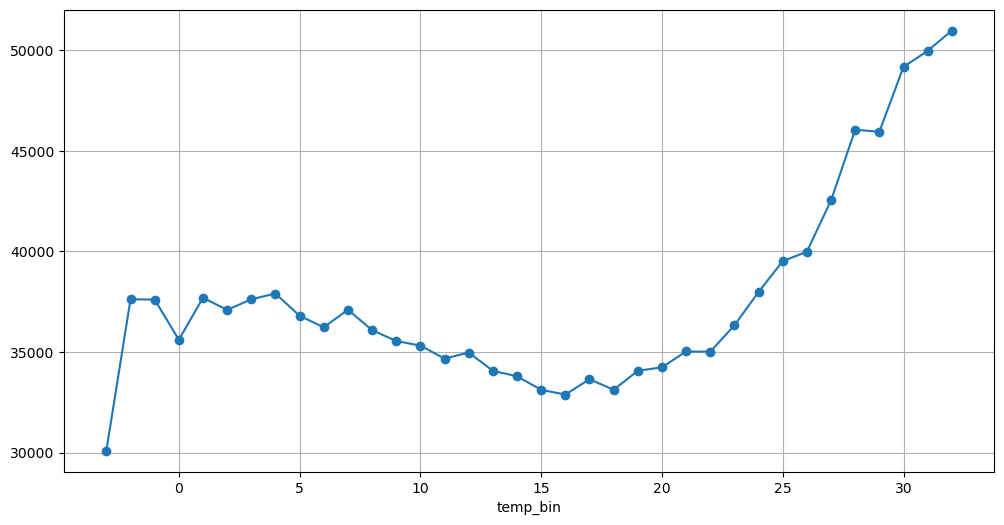

In [ ]:
#Determination of T_Base

# Daily Level
daily = merged_df.resample("D", on="date").agg({
    "consumption": "mean",
    "national_temp": "mean"
})

#Divide Temp into 1C, take mean
daily["temp_bin"] = daily["national_temp"].round()
curve = daily.groupby("temp_bin")["consumption"].mean()

curve.plot(marker="o", figsize=(12, 6), grid=True)

In [11]:
from pathlib import Path
MERGED_PATH = (
    Path.cwd().parent
    / "data"
    / "processed"
    / "merged_data.parquet"
)
merged_df.to_parquet(MERGED_PATH, index=False)